# Household Energy Consumption - Exploratory Data Analysis (EDA)

This notebook loads the cleaned and resampled hourly energy consumption dataset to perform exploratory data analysis. Visualizing the time series at various resolutions (hourly, daily, monthly) and analyzing its distribution helps identify underlying temporal structures, seasonality, trends, and extreme values.

## Setup and Library Imports

We import data handling tools (`pandas`, `numpy`) and visualization libraries (`matplotlib.pyplot`, `seaborn`) to produce plots.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

## Load the Cleaned Dataset

We load the resampled hourly data saved during the cleaning phase. We ensure the `Datetime` column is parsed back into index timestamps.

In [2]:
hourly = pd.read_csv(
    r"C:\Users\Waleed Qamar\Downloads\energy-forecasting\data\household_power_consumption_cleaned.txt",
    parse_dates=["Datetime"],
    index_col="Datetime"
)

## Hourly Energy Consumption

We plot the full hourly energy consumption series. This high-frequency plot shows overall variations, cyclical patterns, and outliers over the years.

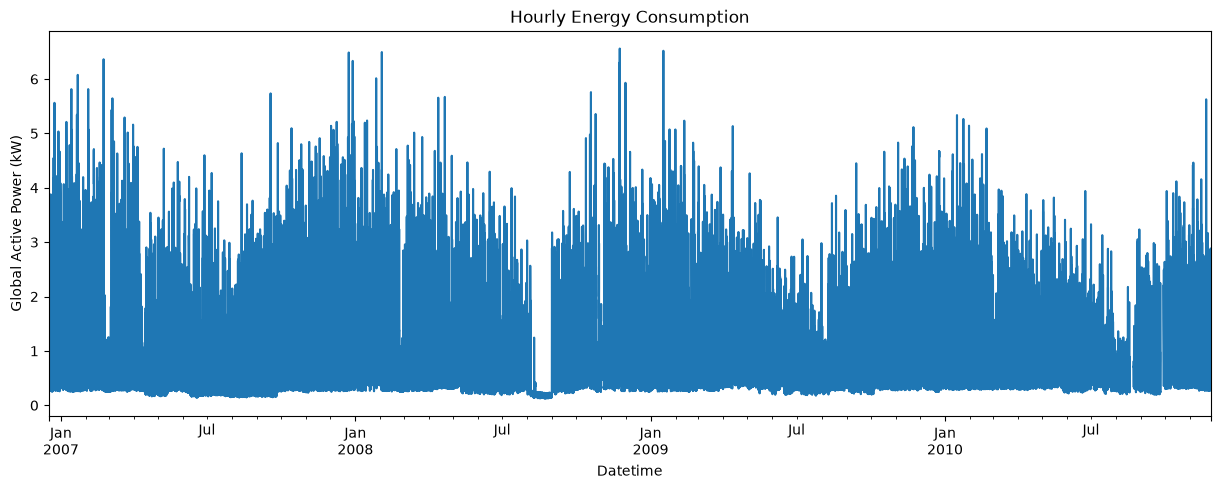

In [7]:
hourly["Global_active_power"].plot(figsize=(15,5))
plt.title('Hourly Energy Consumption')
plt.ylabel('Global Active Power (kW)')
plt.xlabel('Datetime')
plt.savefig('../images/hourly_energy_consumption.png', bbox_inches='tight')
plt.show()

## Daily Consumption Trend

By resampling the hourly data to daily averages (`D`), we smooth out diurnal fluctuations to highlight day-to-day patterns, weekly cycles, and medium-term seasonal variations.

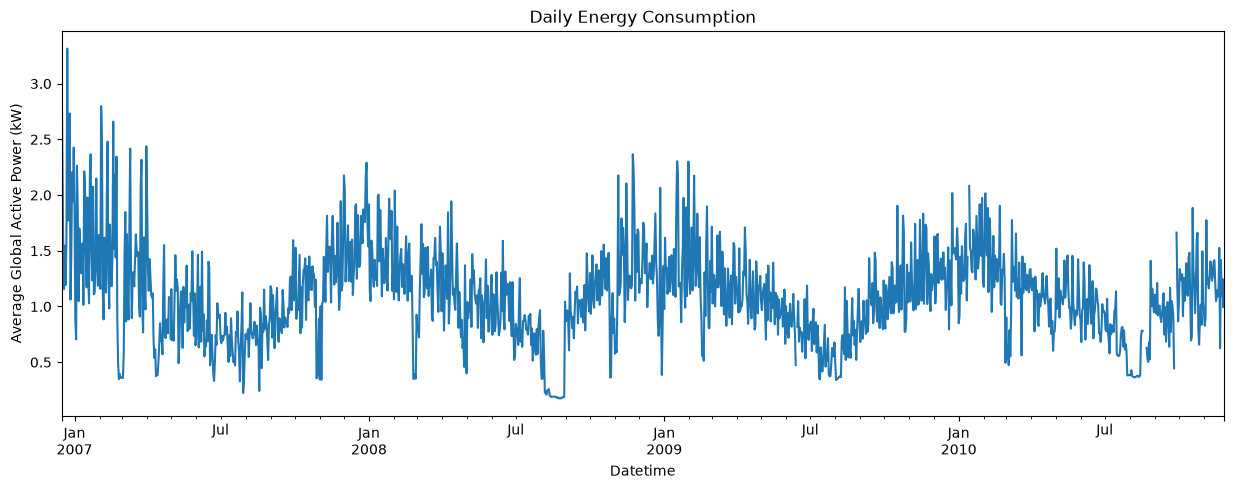

In [8]:
daily = hourly.resample("D").mean()

daily["Global_active_power"].plot(figsize=(15,5))
plt.title('Daily Energy Consumption')
plt.ylabel('Average Global Active Power (kW)')
plt.xlabel('Datetime')

plt.savefig('../images/daily_consumption_trend.png', bbox_inches='tight')

plt.show()

## Monthly Consumption Trend

We resample the hourly data to monthly averages (`ME`) to filter out short-term fluctuations. This exposes long-term annual seasonality, showing peaks in winter months (heating/lighting demand) and dips in summer.

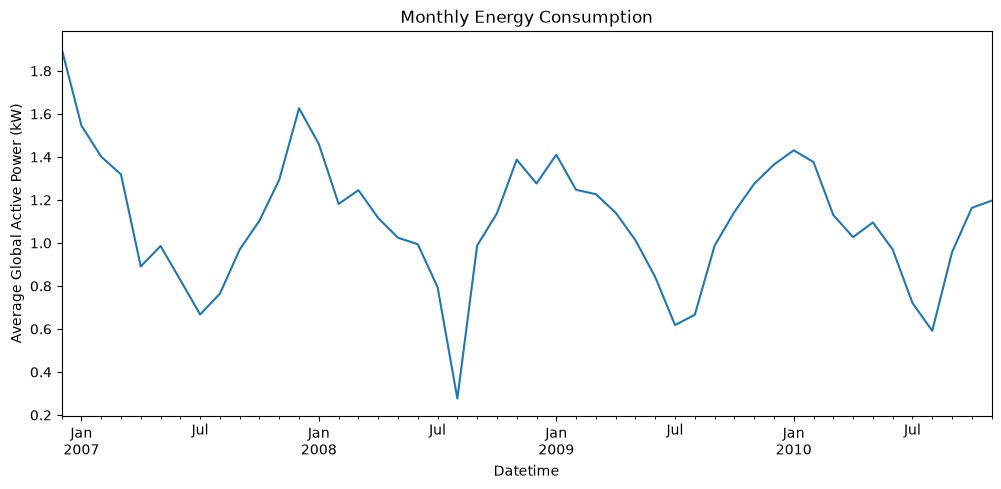

In [9]:
monthly = hourly.resample("ME").mean()

monthly["Global_active_power"].plot(figsize=(12,5))
plt.title('Monthly Energy Consumption')
plt.ylabel('Average Global Active Power (kW)')
plt.xlabel('Datetime')
plt.savefig('../images/monthly_consumption_trend.png', bbox_inches='tight')
plt.show()

## Value Distribution of Global Active Power

We use a histogram to visualize the distribution of `Global_active_power`. This helps check for skewness and find the most common consumption levels.

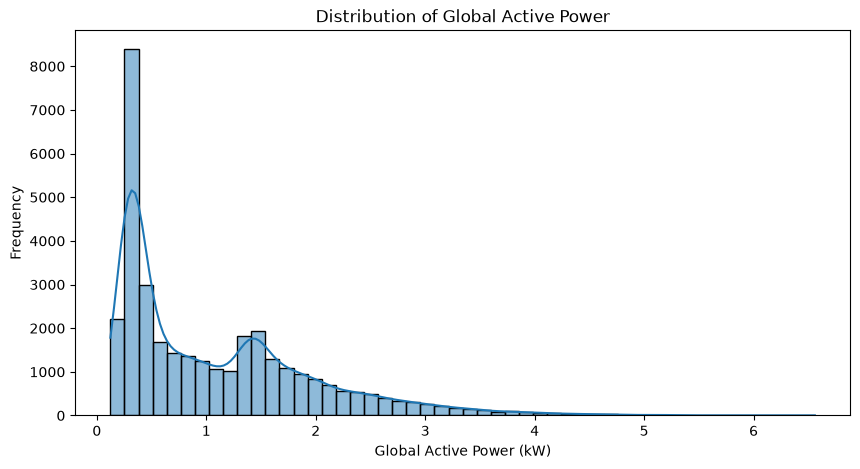

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(hourly["Global_active_power"], bins=50, kde=True)
plt.title('Distribution of Global Active Power')
plt.xlabel('Global Active Power (kW)')
plt.ylabel('Frequency')
plt.savefig('../images/distribution_of_global_active_power.png', bbox_inches='tight')

plt.show()

## Box Plot for Range and Outlier Detection

We generate a box plot of `Global_active_power`. This graph highlights median consumption, interquartile range (IQR), and showcases extreme values (outliers) beyond the whiskers.

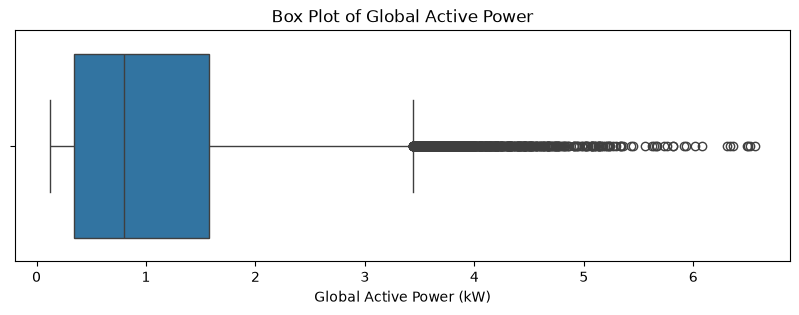

In [11]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=hourly["Global_active_power"])
plt.title('Box Plot of Global Active Power')
plt.xlabel('Global Active Power (kW)')
plt.savefig('../images/boxplot_of_global_active_power.png', bbox_inches='tight')

plt.show()